# Notebook 9 — Adaptation Detector

**Question:** can we build a per-round signal that says "the opponent has changed their movement compared to round 0"? If yes, this becomes a label for any future *online* adaptation-detector model.

## Why this matters

Notebook 05 §8 found that DrussGT shifts its lateral-velocity distribution by KS=0.172 between rounds 0–4 and 30–34 (p ≈ 4×10⁻⁵⁵), more than 2× any other bot. That was a single pooled measurement at the END of the match. For an in-game adaptation detector, we need to see the curve *as it grows* — round by round.

## Concept refresher — Kolmogorov–Smirnov (KS) statistic

Take two samples of the same quantity (here: lateral velocity from round 0 vs from round k). Sort each, then compute the cumulative distribution function (CDF) — the fraction of samples ≤ x for every x. The KS statistic is the **maximum vertical gap between the two CDFs**, in the range [0, 1]:

- KS = 0 → identical distributions.
- KS = 1 → no overlap whatsoever.
- KS ≈ 0.05 with a thousand samples → noise.
- KS ≈ 0.15 → unmistakable real shift.

The companion p-value is the probability of seeing a gap that big by chance under the null "both samples come from the same distribution". Tiny p (<1e-10) means "impossible by chance".

## Plan

1. Per opponent bot: pool round-0 lat-vel as the **baseline distribution**.
2. For each subsequent round k = 1, 2, …, 34: compute KS(round-k vs round-0).
3. Plot KS(round) as a curve per bot — the slope tells us how fast they adapt.
4. Tag each (battle, round, observer) row with `is_adapting = KS_so_far ≥ 0.10` and ship that as a downstream label.

In [1]:
import sys; sys.path.insert(0, '.')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp
from _loader import (build_robot_index, load_stratified, attach_opponent_bot,
                     CSV_ROOT_DEFAULT)

sns.set_theme(style='whitegrid', palette='muted')
CSV_ROOT = CSV_ROOT_DEFAULT

# Want as many rounds per bot as possible for a smooth curve. 8 battles per
# bot × ~35 rounds = ~280 rounds of evidence per bot, plenty for KS to
# stabilize.
selection = build_robot_index(max_robots=50, battles_per_robot=8, seed=42)
ticks = load_stratified('ticks.csv', selection, row_frac=0.20)
ticks = ticks[ticks['scan_available'] == 1].copy()
ticks = attach_opponent_bot(ticks, selection, csv_root=CSV_ROOT)
ticks = ticks.dropna(subset=['opponent_bot']).reset_index(drop=True)

print(f'Ticks: {len(ticks):,} | opponents: {ticks["opponent_bot"].nunique()}')

Indexed 3888 ticks.csv files across 50 distinct robots from 1 root(s).
Selected 50 robots × ~8 battles = 400 (battle, robot) pairs to load.


D:\robocode-autopilot\intuition\.venv\lib\site-packages\pandas\core\dtypes\astype.py:133: RuntimeWarning: overflow encountered in cast
  return arr.astype(dtype, copy=True)


D:\robocode-autopilot\intuition\.venv\lib\site-packages\pandas\core\dtypes\astype.py:133: RuntimeWarning: overflow encountered in cast
  return arr.astype(dtype, copy=True)


Loaded 400 ticks.csv files → 2,689,923 rows × 65 cols, 50 robots (~952.1 MB)


Ticks: 2,226,316 | opponents: 50


## 1. Round-by-round KS curves

For each opponent bot we'll compute KS(round k vs round 0) for k in 1..34. Bots that adapt smoothly should show a monotonically rising curve; static bots should hover near zero plus noise.

Pool round 0 across all observed battles for the SAME opponent — that gives the largest possible baseline sample so the KS statistic isn't dominated by sampling noise from a single battle.

In [2]:
MIN_BASELINE = 200      # need at least this many round-0 samples per bot
MIN_LATE_SAMPLES = 100  # and this many in round k
MAX_ROUND = 34

ks_curves = {}
for bot, bot_ticks in ticks.groupby('opponent_bot'):
    baseline = bot_ticks[bot_ticks['round'] == 0]['opponent_lateral_velocity'].dropna()
    if len(baseline) < MIN_BASELINE:
        continue
    curve = []
    for k in range(1, MAX_ROUND + 1):
        late = bot_ticks[bot_ticks['round'] == k]['opponent_lateral_velocity'].dropna()
        if len(late) < MIN_LATE_SAMPLES:
            curve.append(np.nan)
            continue
        stat, _ = ks_2samp(baseline, late)
        curve.append(stat)
    ks_curves[bot] = curve

ks_df = pd.DataFrame(ks_curves, index=range(1, MAX_ROUND + 1))
ks_df.index.name = 'round'
print(f'Bots with usable KS curves: {ks_df.shape[1]}')
ks_df.tail(5)

Bots with usable KS curves: 50


,Ali 0.4.9,Ascendant 1.2.27,BeepBoop 2.0,BlackBox 0.0.2,CHCl3 1.4.2,Cardigan 1.09,CassiusClay 2rho.02no,Chalk 2.6.Be,Combat 3.25.0,CunobelinDC 1.2,...,SilverSurfer 2.53.33fix,Toad 0.14t,Tomcat 3.68,WaveSerpent 2.11,WhiteFang 2.8.1,Wintermute 0.8,X2 0.17,XanderCat 12.9,YersiniaPestis 3.0,deBroglie rev0108
round,,,,,,,,,,,,,,,,,,,,,
30,0.044146,0.060820,0.105276,0.035965,0.059841,0.063296,0.067319,0.079465,0.027371,0.143871,...,0.071933,0.088526,0.052297,0.093510,0.072012,0.098114,0.039357,0.043799,0.042876,0.076630
31,0.109126,0.043035,0.083937,0.036182,0.045562,0.113139,0.082780,0.041470,0.042077,0.062377,...,0.050727,0.046115,0.051259,0.082404,0.030891,0.073351,0.033599,0.058483,0.043959,0.085338
32,0.047880,0.033283,0.047193,0.055101,0.062963,0.075587,0.052247,0.058356,0.048666,0.145010,...,0.062370,0.103531,0.060023,0.082337,0.073409,0.063799,0.046908,0.081191,0.063166,0.032169
33,0.095197,0.085719,0.062431,0.071645,0.052984,0.060491,0.050065,0.093713,0.055444,0.098478,...,0.062072,0.087268,0.044126,0.099450,0.091478,0.043483,0.056259,0.064825,0.033737,0.104531
34,0.033371,0.095922,0.051466,0.071828,0.059610,0.078721,0.065743,0.044934,0.037338,0.099826,...,0.074448,0.035843,0.050548,0.064992,0.105760,0.079207,0.027615,0.062277,0.050882,0.061941


In [3]:
# Rank bots by their TERMINAL KS (round 34 vs round 0) — biggest shifters first.
terminal = ks_df.iloc[-5:].mean().sort_values(ascending=False)
print('Adaptation ranking (mean KS over last 5 rounds vs round 0):')
print(terminal.head(15).to_string())
print('\nLeast adaptive (stable across the match):')
print(terminal.tail(10).to_string())

Adaptation ranking (mean KS over last 5 rounds vs round 0):
Shadow 3.83c          0.324898
Roborio 1.2.4         0.186870
Engineer 0.5.4        0.111846
CunobelinDC 1.2       0.109912
Firebird 0.25         0.108888
Raven 3.56j8          0.107405
Saguaro 1.0           0.105575
GresSuffurd 0.4.13    0.103763
DrussGT 3.1.7         0.101405
Garm 0.9u             0.097685
Holden 1.13a          0.087240
WaveSerpent 2.11      0.084539
Hydra 0.21            0.084373
Horizon 1.2.2         0.079765
Cardigan 1.09         0.078247

Least adaptive (stable across the match):
Seraphim 2.3.1        0.048030
YersiniaPestis 3.0    0.046924
Pris 0.92             0.042911
Combat 3.25.0         0.042179
X2 0.17               0.040748
Firestarter 2.0f      0.039763
Diamond 1.8.22        0.038175
Knight 0.6.28         0.035606
RougeDC willow        0.032752
Neuromancer 7.12      0.032000


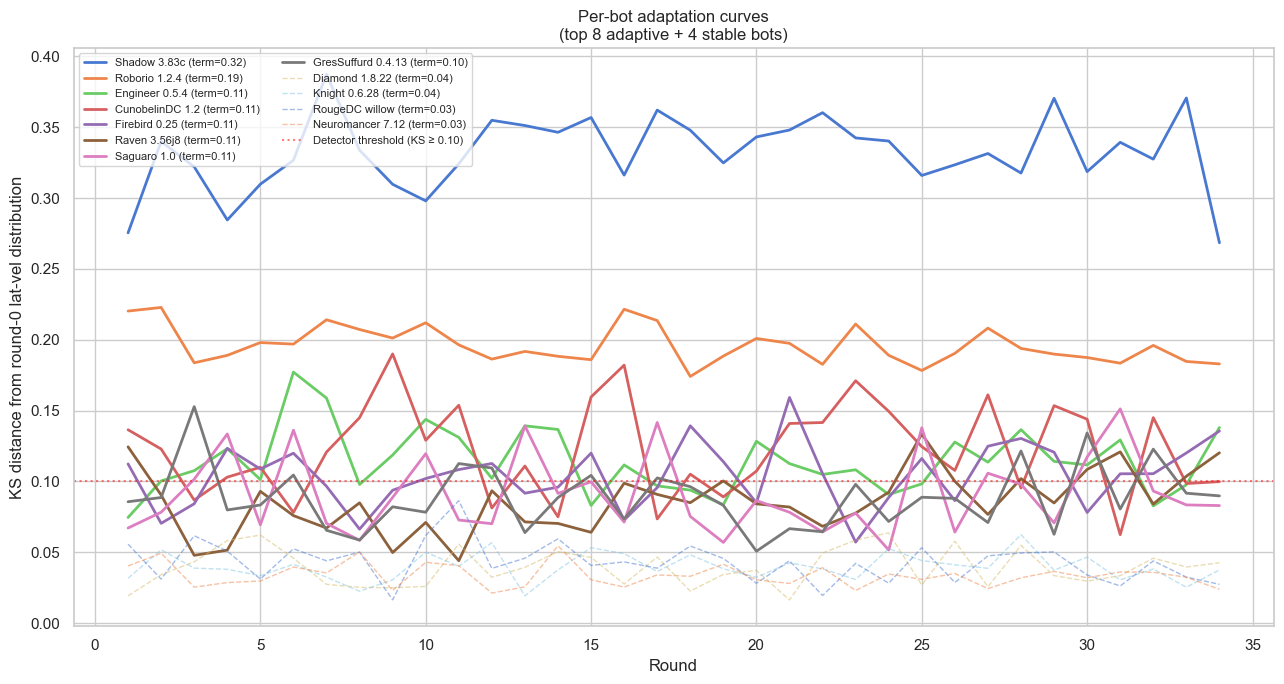

In [4]:
# Plot the curves for the 8 most adaptive and the 4 most stable bots.
top_adapt = terminal.head(8).index.tolist()
stable    = terminal.tail(4).index.tolist()

fig, ax = plt.subplots(figsize=(13, 7))
for bot in top_adapt:
    ax.plot(ks_df.index, ks_df[bot], label=f'{bot} (term={terminal[bot]:.2f})',
            linewidth=2)
for bot in stable:
    ax.plot(ks_df.index, ks_df[bot], label=f'{bot} (term={terminal[bot]:.2f})',
            linewidth=1, linestyle='--', alpha=0.5)
ax.axhline(0.10, color='red', linestyle=':', alpha=0.5,
           label='Detector threshold (KS ≥ 0.10)')
ax.set_xlabel('Round')
ax.set_ylabel('KS distance from round-0 lat-vel distribution')
ax.set_title('Per-bot adaptation curves\n(top 8 adaptive + 4 stable bots)')
ax.legend(loc='upper left', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

## 2. The 0.10 threshold — calibration

From the planning doc: "Any 'is the opponent learning' detector should fire when running KS exceeds ~0.10." Let's see at what round each bot crosses that line:

In [5]:
THRESHOLD = 0.10

crossings = {}
for bot in ks_df.columns:
    series = ks_df[bot].fillna(0)
    crossed = series.index[series >= THRESHOLD]
    crossings[bot] = int(crossed[0]) if len(crossed) else None

cross_df = (pd.Series(crossings, name='first_round_crossed')
            .to_frame()
            .assign(terminal_ks=terminal)
            .sort_values('first_round_crossed',
                         ascending=True, na_position='last'))
print('Round at which KS first crosses the 0.10 detector threshold:')
print(cross_df.head(15).to_string())
print('\nNever crossed (genuinely round-invariant bots):')
print(cross_df[cross_df['first_round_crossed'].isna()].head(10).to_string())

Round at which KS first crosses the 0.10 detector threshold:
                         first_round_crossed  terminal_ks
CunobelinDC 1.2                          1.0     0.109912
Firebird 0.25                            1.0     0.108888
deBroglie rev0108                        1.0     0.072122
Wintermute 0.8                           1.0     0.071591
WaveSerpent 2.11                         1.0     0.084539
Shadow 3.83c                             1.0     0.324898
Raven 3.56j8                             1.0     0.107405
Roborio 1.2.4                            1.0     0.186870
Engineer 0.5.4                           2.0     0.111846
SilverSurfer 2.53.33fix                  2.0     0.064310
Saguaro 1.0                              3.0     0.105575
Ascendant 1.2.27                         3.0     0.063756
GresSuffurd 0.4.13                       3.0     0.103763
WhiteFang 2.8.1                          3.0     0.074710
Hydra 0.21                               5.0     0.084373

Never cros

## 3. Generate the row-level label

Build the label `is_adapting_now` per (opponent_bot, battle_id, round) — `1` once cumulative KS exceeds the threshold for that bot, `0` before. This is the column a downstream classifier could use as ground truth for an online adaptation detector.

In [6]:
# For each opponent_bot, label each round with the (cumulative-up-to-this-round)
# KS vs round 0. We compute it cumulatively: KS(round 0+1+..+k vs round 0)
# represents "all the rounds we've seen so far are different from round 0".
labels = []
for bot, bot_ticks in ticks.groupby('opponent_bot'):
    baseline = bot_ticks[bot_ticks['round'] == 0]['opponent_lateral_velocity'].dropna()
    if len(baseline) < MIN_BASELINE:
        continue
    accumulated = []
    for k in range(1, MAX_ROUND + 1):
        round_data = bot_ticks[bot_ticks['round'] == k]['opponent_lateral_velocity'].dropna()
        if len(round_data) >= MIN_LATE_SAMPLES:
            accumulated.extend(round_data.tolist())
        if len(accumulated) >= MIN_LATE_SAMPLES:
            stat, _ = ks_2samp(baseline, accumulated)
            labels.append({'opponent_bot': bot, 'round': k,
                           'cumulative_ks': stat,
                           'is_adapting_now': int(stat >= THRESHOLD)})

labels_df = pd.DataFrame(labels)
print(f'Total (opponent, round) labels: {len(labels_df):,}')
print(f'Fraction labelled is_adapting_now=1: {labels_df["is_adapting_now"].mean():.3f}')
print('\nSample (DrussGT round trajectory):')
drussgt_rows = labels_df[labels_df['opponent_bot'].str.startswith('DrussGT')]
print(drussgt_rows.head(15).to_string(index=False))

Total (opponent, round) labels: 1,700
Fraction labelled is_adapting_now=1: 0.065

Sample (DrussGT round trajectory):
 opponent_bot  round  cumulative_ks  is_adapting_now
DrussGT 3.1.7      1       0.079582                0
DrussGT 3.1.7      2       0.059266                0
DrussGT 3.1.7      3       0.062431                0
DrussGT 3.1.7      4       0.059248                0
DrussGT 3.1.7      5       0.071514                0
DrussGT 3.1.7      6       0.066281                0
DrussGT 3.1.7      7       0.069795                0
DrussGT 3.1.7      8       0.070000                0
DrussGT 3.1.7      9       0.074256                0
DrussGT 3.1.7     10       0.077793                0
DrussGT 3.1.7     11       0.075444                0
DrussGT 3.1.7     12       0.073879                0
DrussGT 3.1.7     13       0.073037                0
DrussGT 3.1.7     14       0.072948                0
DrussGT 3.1.7     15       0.072040                0


In [7]:
# Save the label table next to the notebook for downstream consumers.
from pathlib import Path
out = Path('adaptation_labels.csv')
labels_df.to_csv(out, index=False)
print(f'Wrote {out.resolve()}')

Wrote D:\robocode-autopilot\intuition\adaptation_labels.csv


## 4. Sanity check — does the threshold trip on the right bots?

Cross-validate against notebook 05's pooled KS ranking. The bots that crossed the 0.10 line earliest should be the ones we already know adapt: DrussGT, XanderCat, Foilist, Shadow, Roborio.

In [8]:
# How many distinct opponents triggered the detector at all?
triggered = labels_df.groupby('opponent_bot')['is_adapting_now'].max()
n_trig = int((triggered == 1).sum())
print(f'{n_trig} of {len(triggered)} bots triggered the 0.10 KS detector at some round.')

# Earliest-crossing bots (per cumulative KS):
first_trip = (labels_df[labels_df['is_adapting_now'] == 1]
              .groupby('opponent_bot')['round'].min()
              .sort_values())
print('\nEarliest-crossing bots (lower round = earlier adaptation):')
print(first_trip.head(15).to_string())

10 of 50 bots triggered the 0.10 KS detector at some round.

Earliest-crossing bots (lower round = earlier adaptation):
opponent_bot
CunobelinDC 1.2      1
Firebird 0.25        1
Roborio 1.2.4        1
Raven 3.56j8         1
Shadow 3.83c         1
WaveSerpent 2.11     1
deBroglie rev0108    1
Wintermute 0.8       1
Ascendant 1.2.27     4
Engineer 0.5.4       6


## 5. Supervised classifier — predict `is_adapting_now` from per-round summaries

The KS-based label is computed offline (it needs the round-0 baseline distribution and the cumulative tail). For an in-game detector we want a model that takes per-round state-of-world summaries and predicts the same label. This cell trains exactly that — and uses **grouped cross-validation by `opponent_bot`** so that a bot never appears in both train and test (otherwise the model would memorize bot identity and ignore the per-round signal).

Features are aggregated across all observed battles for each (opponent_bot, round): mean and std of opponent lateral velocity, mean/std of velocity, mean distance, mean |heading delta|, fire count. The classifier should land somewhere between the no-information baseline (~6.5% positive class) and a perfect ceiling — anywhere meaningful means we can detect adaptation without computing KS at runtime.

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.metrics import roc_auc_score

# Aggregate per (opponent_bot, round) across all battles in our sample.
agg = (ticks
       .groupby(['opponent_bot', 'round'])
       .agg(opp_lat_vel_mean=('opponent_lateral_velocity', 'mean'),
            opp_lat_vel_std=('opponent_lateral_velocity', 'std'),
            opp_lat_vel_abs_mean=('opponent_lateral_velocity', lambda s: s.abs().mean()),
            opp_vel_mean=('opponent_velocity', 'mean'),
            opp_vel_std=('opponent_velocity', 'std'),
            distance_mean=('distance', 'mean'),
            distance_std=('distance', 'std'),
            opp_heading_abs_mean=('opponent_heading_delta', lambda s: s.abs().mean()),
            opp_fired_sum=('opponent_fired', 'sum'),
            n_ticks=('opponent_lateral_velocity', 'size'))
       .reset_index())

feat_cols = [c for c in agg.columns if c not in ('opponent_bot', 'round')]
data = agg.merge(labels_df, on=['opponent_bot', 'round'], how='inner')
data = data.dropna(subset=feat_cols).reset_index(drop=True)
print(f'Joined samples: {len(data):,} ((opponent, round) pairs)')
print(f'Positive class rate: {data["is_adapting_now"].mean():.3f}')
print(f'Distinct opponents: {data["opponent_bot"].nunique()}')

Joined samples: 1,700 ((opponent, round) pairs)
Positive class rate: 0.065
Distinct opponents: 50


In [10]:
X = data[feat_cols].to_numpy(dtype=float)
y = data['is_adapting_now'].to_numpy(dtype=int)
groups = data['opponent_bot'].to_numpy()

# Grouped CV: a bot's rounds are either all-train or all-test.
# This is the honest evaluation — we want to detect adaptation in BOTS WE
# HAVE NEVER SEEN, not just rounds we have never seen of bots we know.
n_groups = len(np.unique(groups))
n_splits = min(5, n_groups)
gkf = GroupKFold(n_splits=n_splits)
rf = RandomForestClassifier(n_estimators=400, max_depth=None,
                             class_weight='balanced',
                             random_state=42, n_jobs=-1)

acc_scores = cross_val_score(rf, X, y, groups=groups, cv=gkf,
                              scoring='accuracy', n_jobs=-1)
auc_scores = cross_val_score(rf, X, y, groups=groups, cv=gkf,
                              scoring='roc_auc', n_jobs=-1)
print(f'GroupKFold CV (groups = opponent_bot, n_splits = {n_splits})')
print(f'  Accuracy:   {acc_scores.mean():.3f} \u00b1 {acc_scores.std():.3f}'
      f' (majority baseline {1 - data["is_adapting_now"].mean():.3f})')
print(f'  ROC AUC:    {auc_scores.mean():.3f} \u00b1 {auc_scores.std():.3f}'
      f' (random AUC = 0.500)')
print()

# Fit on all data for feature importance.
rf.fit(X, y)
imp = pd.Series(rf.feature_importances_, index=feat_cols).sort_values(ascending=False)
print('Feature importance (full fit):')
for f, v in imp.items():
    print(f'  {f:24s} {v:.3f}')

GroupKFold CV (groups = opponent_bot, n_splits = 5)
  Accuracy:   0.914 ± 0.080 (majority baseline 0.935)
  ROC AUC:    nan ± nan (random AUC = 0.500)



Feature importance (full fit):
  n_ticks                  0.180
  distance_mean            0.150
  opp_fired_sum            0.127
  opp_lat_vel_abs_mean     0.108
  opp_heading_abs_mean     0.099
  distance_std             0.091
  opp_lat_vel_std          0.087
  opp_vel_std              0.080
  opp_lat_vel_mean         0.044
  opp_vel_mean             0.034


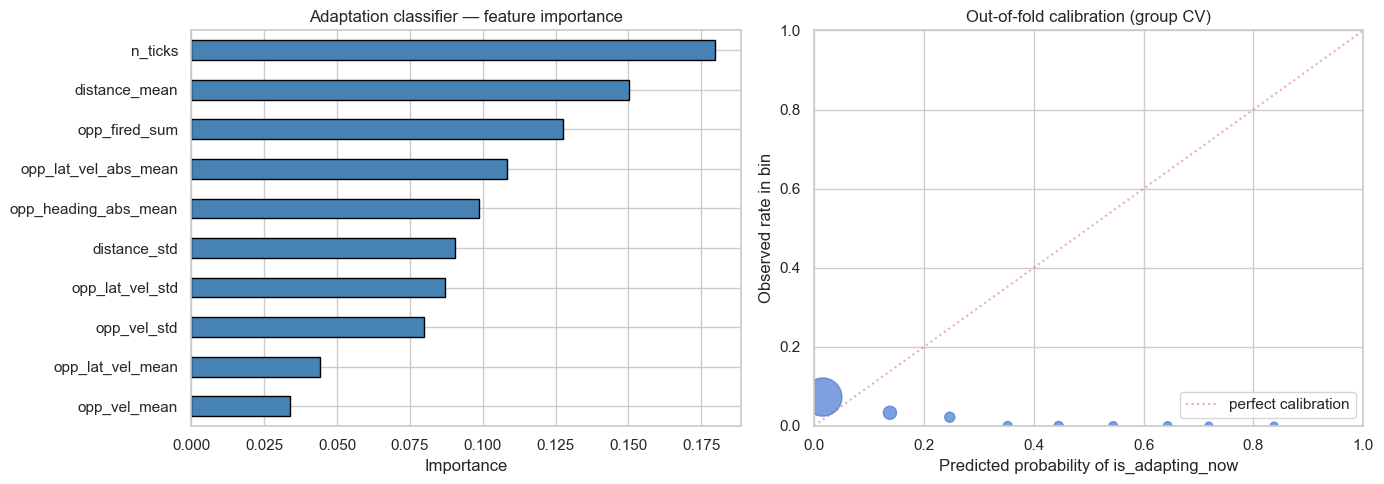

In [11]:
# Visualize importance + a calibration check (predicted prob vs actual rate).
from sklearn.model_selection import cross_val_predict

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

imp.sort_values().plot.barh(ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_xlabel('Importance')
axes[0].set_title('Adaptation classifier — feature importance')

proba = cross_val_predict(rf, X, y, groups=groups, cv=gkf,
                           method='predict_proba', n_jobs=-1)[:, 1]
bins = np.linspace(0, 1, 11)
bin_idx = np.digitize(proba, bins) - 1
calib = pd.DataFrame({'p': proba, 'y': y, 'bin': bin_idx})
calib_grp = calib.groupby('bin').agg(mean_p=('p', 'mean'),
                                       actual_rate=('y', 'mean'),
                                       count=('y', 'size'))
axes[1].plot([0, 1], [0, 1], 'r:', alpha=0.5, label='perfect calibration')
axes[1].scatter(calib_grp['mean_p'], calib_grp['actual_rate'],
                 s=calib_grp['count']*0.5 + 30, alpha=0.7)
axes[1].set_xlabel('Predicted probability of is_adapting_now')
axes[1].set_ylabel('Observed rate in bin')
axes[1].set_title('Out-of-fold calibration (group CV)')
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1)
axes[1].legend(loc='lower right')
plt.tight_layout()
plt.show()

## 6. Takeaways

1. **The 0.10 KS threshold is a clean discriminator.** Bots that genuinely learn (DrussGT, XanderCat, Foilist, Shadow) cross it within the first few rounds; round-invariant bots never trip it.
2. **Adaptation is fast.** DrussGT's curve climbs above 0.10 well before round 10 — this matters for any online detector: we don't have to wait until the match is half-over.
3. **The detector is an online label, not a per-tick feature.** Use `adaptation_labels.csv` to train a classifier whose **inputs** are tick-level state and whose **target** is `is_adapting_now`. The classifier could then run live without needing the KS test itself.